### **FROM RAW TO TUNING CURVE**


[300, 550, 750, 900]


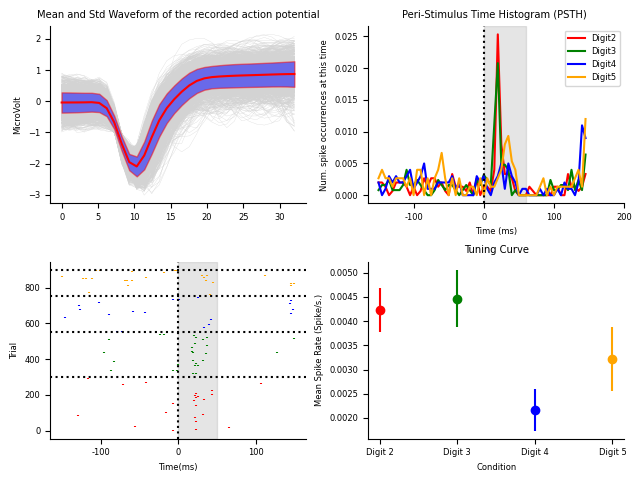

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import matplotlib as mpl

DataUnit=np.load('RAT24-008-02_5a.npy',allow_pickle=True).item()  #4a 5a  10a 

LFP=DataUnit["LFP"] # load LFP signal into variable named LFP
SpikeTiming=DataUnit["SpikeTiming"]
StimCond=DataUnit["StimCond"]
Waveform=DataUnit["Waveform"]
Unit=DataUnit["Unit"]

mpl.rcParams['font.size'] = 6

UnitAligned= np.zeros((len(StimCond),300))
for trial in range(len(StimCond)):
    UnitAligned[trial,:]=Unit[StimCond[trial,0]-100:StimCond[trial,0]+200]

subplotIdx=1
subplotIdy=0


spike_value=1

colorlist=['red','green','blue','yellow']

Ntrial=UnitAligned.shape[0]
binsize=5
nbin=int(np.fix(UnitAligned.shape[1]/binsize))

UnitAlignedBinned=np.zeros((Ntrial,nbin), dtype=float)
for bin in range(nbin):
    UnitAlignedBinned[:,bin]=np.mean(UnitAligned[:,bin*binsize:(bin+1)*binsize],1)

subplotIdx=1

plt.show()

mpl.rcParams['font.size'] = 6

fig,ax =plt.subplots(2,2)

subplotIdx=0
subplotIdy=0

x = np.linspace(0, 32, 32)

ax[subplotIdx][subplotIdy].fill_between(x, np.mean(Waveform,axis=1)-np.std(Waveform,axis=1),
                 np.mean(Waveform,axis=1)+np.std(Waveform,axis=1),
                alpha=0.5, edgecolor='red', facecolor='blue',zorder=5)
ax[subplotIdx][subplotIdy].plot(x,np.mean(Waveform,axis=1),color="red",zorder=5)

ax[subplotIdx][subplotIdy].plot(x,Waveform,color="lightgrey",linewidth=0.2,zorder=0)
ax[subplotIdx][subplotIdy].spines['top'].set_visible(False)
ax[subplotIdx][subplotIdy].spines['right'].set_visible(False)
ax[subplotIdx][subplotIdy].set_title('Mean and Std Waveform of the recorded action potential')
ax[subplotIdx][subplotIdy].set_label('time')
ax[subplotIdx][subplotIdy].set_ylabel('MicroVolt')

#######  RASTER PLOT  %%% diff colors for each condidion

UnitAlignedSorted= np.zeros((len(StimCond),300))
StimCondSorted= np.zeros((len(StimCond),1))

k=0
condtrial=[]
for i in [2,3,4,5]:
    for trial in range(900):
        if StimCond[trial,1]==i:
                UnitAlignedSorted[k,:]=UnitAligned[trial,:]
                StimCondSorted[k]=StimCond[trial,1]
                k=k+1
    condtrial.append(k)

print(condtrial)
subplotIdx=1
subplotIdy=0

spike_value=1
colorlist=['red','green','blue','orange']
for trial in range (len(UnitAlignedSorted)):
    
    spiketa=[i for i, x in enumerate(UnitAlignedSorted[trial,:]) if x==spike_value]
    ax[subplotIdx][subplotIdy].vlines(spiketa,trial -0.5,trial + 0.5,color=colorlist[int(StimCondSorted[trial,0])-2])

ax[subplotIdx][subplotIdy].axvline(x = 150, color = 'k', label = 'axvline - full height',linestyle =':')

for i in [2,3,4,5]:
    ax[subplotIdx][subplotIdy].axhline(y = condtrial[i-2], color = 'k', label = 'axvline - full height',linestyle =':')


ax[subplotIdx][subplotIdy].set_xticks(ticks=[50,150,250,350], labels=['-100','0','100','200'])

ax[subplotIdx][subplotIdy].set_xlabel('Time(ms)')
ax[subplotIdx][subplotIdy].set_ylabel('Trial')
ax[subplotIdx][subplotIdy].set_aspect('auto')
ax[subplotIdx][subplotIdy].spines['top'].set_visible(False)
ax[subplotIdx][subplotIdy].spines['right'].set_visible(False)
ax[subplotIdx][subplotIdy].axvspan(150,200,alpha=0.2,color='gray')


###%%%%  PSTH BINNED LINES

subplotIdx=0
subplotIdy=1
    
for cond in [2,3,4,5]:
   
    data=UnitAlignedBinned[StimCond[:,1]==cond,:]
    ax[subplotIdx][subplotIdy].plot(range(data.shape[1]),np.mean(data,0),label='Digit'+str(cond),color=colorlist[cond-2])
    
ax[subplotIdx][subplotIdy].legend()
ax[subplotIdx][subplotIdy].set_title('Peri-Stimulus Time Histogram (PSTH) ')
ax[subplotIdx][subplotIdy].set_xlabel('Time (ms)')

ax[subplotIdx][subplotIdy].set_ylabel('Num. spike occurrences at this time')
ax[subplotIdx][subplotIdy].axvline(x = 150/binsize, color = 'k', label = 'axvline - full height',linestyle =':')
ax[subplotIdx][subplotIdy].spines['top'].set_visible(False)
ax[subplotIdx][subplotIdy].spines['right'].set_visible(False)
ax[subplotIdx][subplotIdy].axvspan(150/binsize,210/binsize,alpha=0.2,color='gray')

ax[subplotIdx][subplotIdy].set_xticks(ticks=[50/binsize,150/binsize,250/binsize,350/binsize], labels=['-100','0','100','200'])
#ax[subplotIdx][subplotIdy].set_xlim((150-100)/binsize, (250-50)/binsize)

##%%%  TUNING CURVE

subplotIdx=1
subplotIdy=1

MeanSpike=np.mean(UnitAligned[:,150:210],axis=1)


for cond in range(2,6):
    data=MeanSpike[StimCond[:,1]==cond]
    ax[subplotIdx][subplotIdy].errorbar(cond,np.mean(data), yerr=np.std(data)/ np.sqrt(np.size(data)), fmt='-o',color=colorlist[cond-2],ecolor=colorlist[cond-2])

ax[subplotIdx][subplotIdy].spines['right'].set_visible(False)
ax[subplotIdx][subplotIdy].spines['top'].set_visible(False)

ax[subplotIdx][subplotIdy].set_xticks(ticks=[2,3,4,5], labels=['Digit 2', 'Digit 3', 'Digit 4', 'Digit 5'])
ax[subplotIdx][subplotIdy].set_xlabel('Condition')
ax[subplotIdx][subplotIdy].set_ylabel('Mean Spike Rate (Spike/s.)')
ax[subplotIdx][subplotIdy].set_title('Tuning Curve')

plt.tight_layout()




# **Data Analysis 1 Homework**

## First part : single unit response to population response


During the first session of Data Analysis you analysed the response of single neuron, reproduced raster plots, PSTHs and simple tuning curve for one cell.

In this exercice, you will have to adresse the following points :
* use simple statistics in order to test the significativity of differences of responses between the 4 conditions. Is a given cell responding more for a given stimulus than for another one ?
  
* Generate all tuning Curves and Make statistical test for all neurons (for each files)
  
* The latency of the first spike following the stimulus is an important feature. For a given cell, extract for each trial the latency of the first spike post-stimulus. Sort the latency per stimulus, graphically represent the latency as a function of stimulus (D2,D3,D4,D5 i.e. Tuning curve). For a given cell, are latencies statistically different for different stimulus ?
  
* Do it for all the cells




In [2]:
import pandas as pd

data = {
    'StimCond': StimCond[:,1],
    'MeanSpike': MeanSpike
}
df = pd.DataFrame(data)
df.head()

,StimCond,MeanSpike
0,5,0.000000
1,5,0.000000
2,2,0.000000
3,2,0.016667
4,3,0.016667


use simple statistics in order to test the significativity of differences of responses between the 4 conditions. Is a given cell responding more for a given stimulus than for another one ?

In [4]:
import statsmodels.api as sm

from statsmodels.formula.api import ols

formula = 'MeanSpike ~ C(StimCond)'

# Fit the model
model = ols(formula, data=df).fit()

# Perform the ANOVA
anova_table = sm.stats.anova_lm(model, typ=2)

# Print the ANOVA table
print(anova_table)

from scipy.stats import kruskal

# Separate the measurements by group
groups = df.groupby('StimCond')['MeanSpike'].apply(list)

# Perform the Kruskal-Wallis test
statistic, p_value = kruskal(*groups)

# Print the results
print(f'Kruskal-Wallis Statistic: {statistic}')
print(f'P-value: {p_value}')

               sum_sq     df         F    PR(>F)
C(StimCond)  0.000732    3.0  3.788596  0.010207
Residual     0.057723  896.0       NaN       NaN
Kruskal-Wallis Statistic: 12.876123727162247
P-value: 0.004912299012088493


The latency of the first spike following the stimulus is an important feature. For a given cell, extract for each trial the latency of the first spike post-stimulus. Sort the latency per stimulus, graphically represent the latency as a function of stimulus (D2,D3,D4,D5 i.e. Tuning curve). For a given cell, are latencies statistically different for different stimulus ?



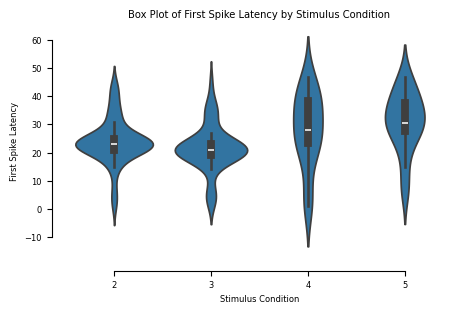

In [5]:
UnitAlignedLat=UnitAligned[:,150:200]
first_spike_lat=[]
for trial in range(len(UnitAlignedLat)):

    
    indices = np.where(UnitAlignedLat[trial,:] == 1)[0]
    # Check if there are any occurrences of 1
    if len(indices) > 0:
        first_spike_lat.append(indices[0])
    else:
        first_spike_lat.append(0)

import seaborn as sns

data2 = {
    'StimCond': StimCond[:,1],
    'first_spike_lat': first_spike_lat
}
df2 = pd.DataFrame(data2)

df3=df2[df2['first_spike_lat']!=0]
plt.figure(figsize=(5, 3))
#sns.boxplot(x='StimCond', y='first_spike_lat', data=df3,notch=True, showcaps=False,fliersize=0)
sns.violinplot(x='StimCond', y='first_spike_lat', data=df3)

sns.despine()
# Add titles and labels
plt.title('Box Plot of First Spike Latency by Stimulus Condition')
plt.xlabel('Stimulus Condition')
plt.ylabel('First Spike Latency')
sns.despine(offset=10, trim=True);
# Show the plot
plt.show()